## SHAP — Explaining Predictions

- SHAP (SHapley Additive exPlanations) is a game-theoretic approach used to explain the output of any machine learning model.  It assigns each feature an importance value for a specific prediction, representing its contribution to the difference between the actual prediction and the average prediction across the dataset.

In [1]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split

xgb_balanced = joblib.load("xgb_balanced.joblib")

df = df = pd.read_csv("cleaned_data.csv", index_col="id")

x = df.drop(columns=["default_payment_next_month"])
y = df["default_payment_next_month"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

xgb_final_model = xgb_balanced

feature_names = xgb_final_model.named_steps["preprocessor"].get_feature_names_out()

In [2]:
import shap

explainer = shap.TreeExplainer(xgb_final_model.named_steps["classifier"])

x_train_trans = xgb_balanced.named_steps["preprocessor"].transform(x_train)
x_test_trans = xgb_balanced.named_steps["preprocessor"].transform(x_test)

shap_values = explainer.shap_values(x_test_trans)

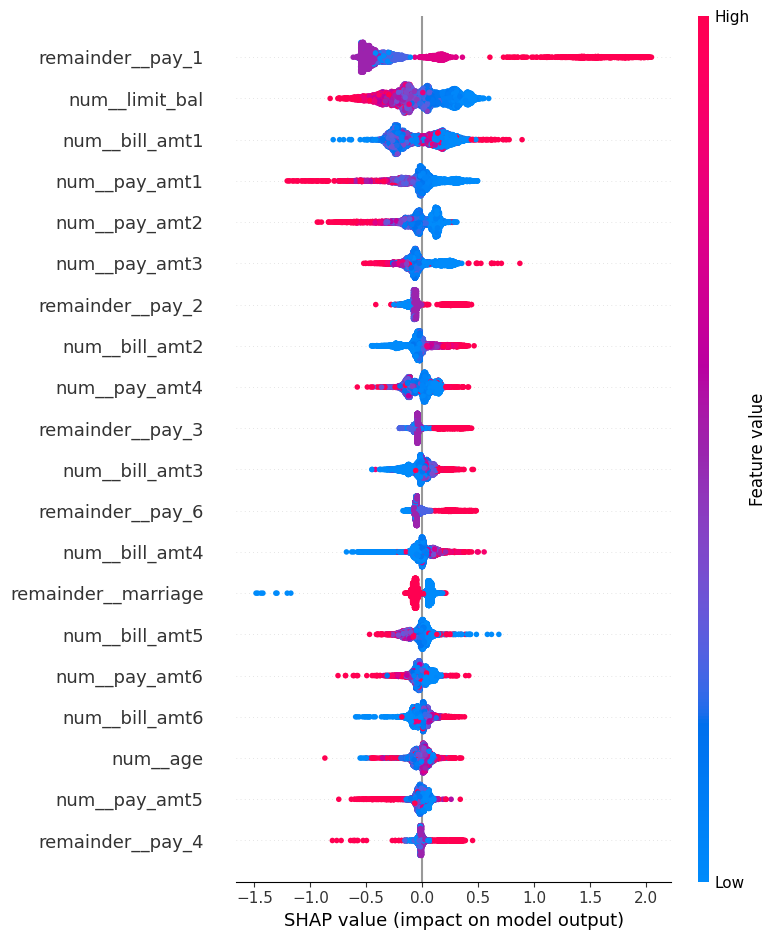

In [3]:
shap.summary_plot(shap_values, x_test_trans, feature_names)

### Which features push predictions toward default?
- Feature `pay_1` (recent repayment status) pushes predictions toward default the most. High values of pay_1 (indicating delayed or missed payments) appear as red points with positive SHAP values, showing that worse recent repayment behavior strongly increases the predicted probability of default.

### Which protect against default?
- Feature `limit_bal` protects against default. Higher credit limits (red points) are associated with negative SHAP values, meaning they push predictions away from default, while lower credit limits increase default risk.

### Does this match domain intuition?
- Yes, this aligns well with domain intuition. Customers with recent delayed or missed payments are inherently higher risk, while customers with higher credit limits generally have stronger credit profiles and are less likely to default.

## Single Prediction Explanation

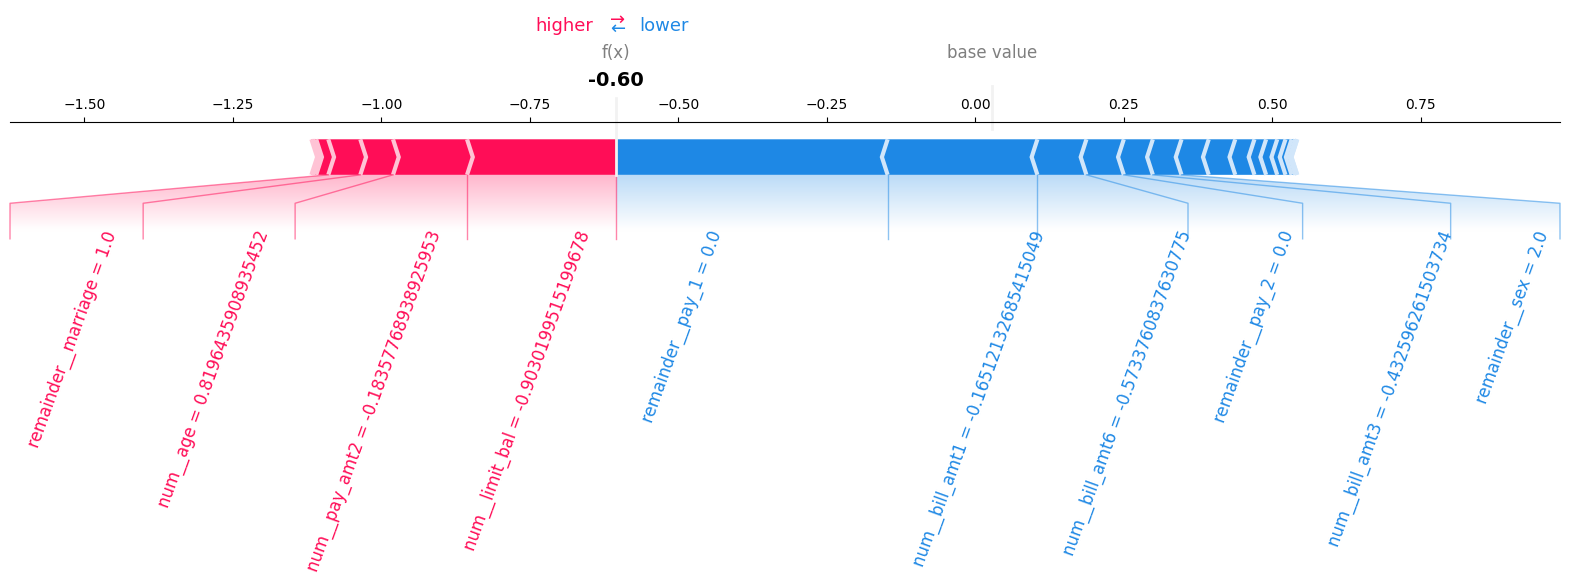

In [4]:
shap.force_plot(explainer.expected_value, shap_values[0], x_test_trans[0], feature_names, matplotlib=True, text_rotation=70)

### Why the model predicted non-default?
- The model predicted non-default because the combined SHAP contributions of individual features move the prediction from the base value down to a final model output of −0.60, indicating lower default risk.

### Which features pushed hardest?
- Recent repayment status (pay_1 = 0) is one of the strongest features pushing the prediction toward non-default, as timely repayment behavior contributes negatively to the model output. In addition, several bill amount and repayment-related features collectively reinforce this effect.

### Whether this decision seems reasonable?
- Yes, it seems reasonable because `pay_1` is 0 which implies customer is paying bills on time.

## Trust & Failure Analysis

### Where the model is reliable
- The model is most reliable when predictions are driven by strong and consistent repayment behavior signals that align with domain intuition.

### Where it might fail
-  It is less reliable in edge cases with rare feature combinations or conflicting signals, where SHAP explanations show opposing feature contributions.

### Which features could encode bias
- Bias is about what the model relies on, not whether it performs well.
- Certain demographic features such as `marriage`, and `age` could potentially encode bias, as they represent protected or sensitive attributes and may act as proxies for socioeconomic status. However, SHAP analysis shows that these features have relatively small contributions compared to repayment behavior features. The model primarily relies on financial behavior signals, which reduces—but does not eliminate—the risk of biased decision-making.

### What monitoring would be needed in production
- Monitoring such as Data Drifting Monitoring, Prediction Drift Monitoring, Explanation Stability Monitoring (SHAP), Data Quality, etc. This Production monitoring ensures the model continues to receive valid data, make stable predictions, remain fair across segments, and align with business objectives over time.